**Taran's Contribution**

In [1]:
pip install diffusers accelerate torchvision torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 121.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.9/981.9 kB 51.5 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

Dataset Preparation

In [2]:
from google.colab import drive
import zipfile
import os

# Path to your ZIP file (modify this path as needed)
zip_path = "/content/balanced_labeled_photos.zip" # <-- change this

# Destination folder where contents will be extracted
extract_dir = "/content/dataset"

# Create destination folder if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Unzipping completed!")

Unzipping completed!


STEP : Prepare dataset (ImageFolder)


In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np

transform = transforms.Compose([
    transforms.Resize(32),
    transforms.CenterCrop(32),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset_path = "/content/dataset/balanced_labeled_photos"
full_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

# Use only a small subset for fast testing
subset_indices = np.random.choice(len(full_dataset), size=1000, replace=False)
dataset = Subset(full_dataset, subset_indices)

dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

STEP : Define a small UNet model

In [4]:
from diffusers import UNet2DModel, DDPMScheduler
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet2DModel(
    sample_size=32,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 128),
    down_block_types=("DownBlock2D", "DownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "UpBlock2D", "UpBlock2D")
).to(device)

STEP : Diffusion noise scheduler


In [5]:
from diffusers import DDIMScheduler

# Use the same number of training timesteps, but fewer inference steps
noise_scheduler = DDIMScheduler(
    num_train_timesteps=250,  # Keep training setup
    beta_start=0.0001,
    beta_end=0.02,
    beta_schedule="linear",
    clip_sample=False,
    set_alpha_to_one=False
)

STEP : Training loop

In [13]:
import torch.nn.functional as F
from tqdm.auto import tqdm

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
epochs = 100

for epoch in range(epochs):
    model.train()
    pbar = tqdm(enumerate(dataloader), total=len(dataloader))

    for i, (clean_images, _) in pbar:
        clean_images = clean_images.to(device)

        # Add noise
        noise = torch.randn_like(clean_images)
        timesteps = torch.randint(0, noise_scheduler.num_train_timesteps, (clean_images.shape[0],), device=device).long()
        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

        noise_pred = model(noisy_images, timesteps).sample
        loss = F.mse_loss(noise_pred, noise)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if i % 20 == 0:
            pbar.set_description(f"Epoch {epoch+1}, Step {i}, Loss: {loss.item():.4f}")

  0%|          | 0/63 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDIMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDIMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

...

  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

  0%|          | 0/63 [00:00<?, ?it/s]

STEP : Image sampling function

In [16]:
@torch.no_grad()
def sample_images(model, scheduler, num_images=16, inference_steps=25):
    model.eval()
    images = torch.randn((num_images, 3, 32, 32)).to(device)
    scheduler.set_timesteps(inference_steps)

    for t in tqdm(scheduler.timesteps, desc="Sampling"):
        t_tensor = torch.full((num_images,), t, device=device, dtype=torch.long)
        with torch.amp.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu'):
            noise_pred = model(images, t_tensor).sample

        images = scheduler.step(noise_pred, t, images).prev_sample

    images = (images.clamp(-1, 1) + 1) / 2
    return images.cpu()

In [17]:
sampled_images = sample_images(model, noise_scheduler, num_images=16, inference_steps=10)

Sampling:   0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/debugpy/_vendored/pydevd/_pydevd_bundle/pydevd_safe_repr.py:128: FutureWarning: Accessing config attribute `__iter__` directly via 'UNet2DModel' object attribute is deprecated. Please access '__iter__' over 'UNet2DModel's config object instead, e.g. 'unet.config.__iter__'.
  if not hasattr(obj, "__iter__"):


STEP : Generate and visualize images


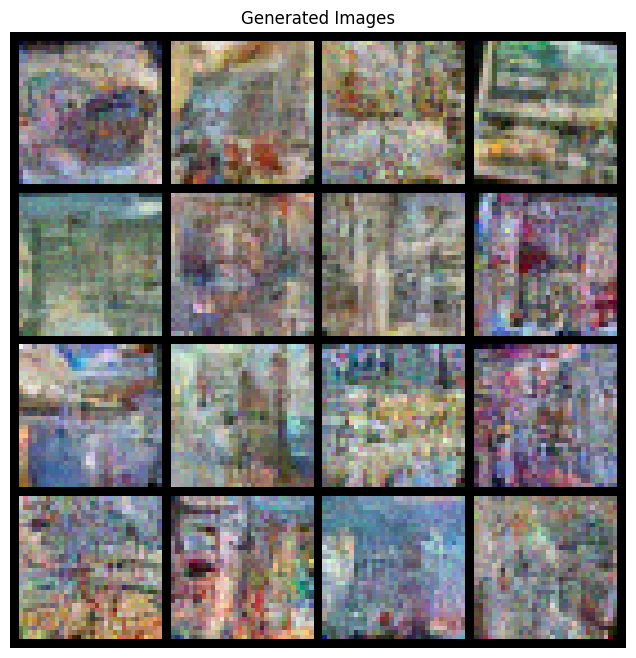

In [18]:
import torchvision.utils as utils
import matplotlib.pyplot as plt

grid = utils.make_grid(sampled_images, nrow=4)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.axis("off")
plt.title("Generated Images")
plt.show()

Final Evaluation

In [19]:
pip install torch-fidelity

In [20]:
!pip install torchmetrics[image]

In [21]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
import torch

#  Use fewer real images for fast eval
real_images_list = []
for i, (imgs, _) in enumerate(dataloader):
    real_images_list.append(imgs)
    if i >= 3:
        break

real_images = torch.cat(real_images_list, dim=0).to(device)
real_images = (real_images.clamp(-1, 1) + 1) / 2
real_images = (real_images * 255).byte()

#  Generate fake images (match real count)
fake_images = sample_images(model, noise_scheduler, num_images=real_images.size(0), inference_steps=25)
fake_images = (fake_images * 255).byte()


# FID
fid = FrechetInceptionDistance(feature=2048).to(device)
fid.update(real_images, real=True)
fid.update(fake_images.to(device), real=False)
fid_score = fid.compute()

# Inception Score
inception = InceptionScore(normalize=True).to(device)
inception.update(fake_images.to(device))
is_mean, is_std = inception.compute()

print(f"FID Score: {fid_score.item():.4f}")
print(f"Inception Score: {is_mean:.4f} ± {is_std:.4f}")

Sampling:   0%|          | 0/25 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


FID Score: 324.8467
Inception Score: 1.7320 ± 0.2949


In [25]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=0c50362b8bed988fb1e500110c696a12f256ce3f1cccbf75fb1daf6978ff4d73
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


  0%|          | 0/100 [00:00<?, ?it/s]

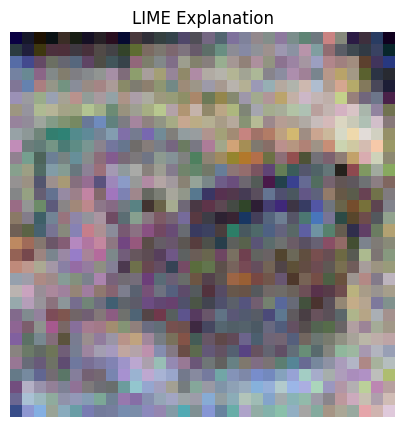

In [26]:
import numpy as np
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt

# Convert one generated image to [0, 255] range and to CPU
image = sampled_images[0].permute(1, 2, 0).numpy()
image = (image * 255).astype(np.uint8)

# Define dummy classifier for LIME (since model is generative)
def dummy_classifier(images):
    # Convert to torch tensors and normalize to [-1, 1]
    imgs = torch.tensor(images).permute(0, 3, 1, 2).float() / 255.0
    imgs = imgs * 2 - 1
    imgs = imgs.to(device)

    # Fake labels for binary classification (dummy)
    with torch.no_grad():
        noise = torch.randn_like(imgs)
        t = torch.full((imgs.shape[0],), 10, dtype=torch.long, device=device)
        output = model(imgs, t).sample
        scores = torch.sigmoid(output.mean(dim=[1,2,3]))  # Dummy score per image

    return torch.stack([scores, 1 - scores], dim=1).cpu().numpy()

# Apply LIME
explainer = lime_image.LimeImageExplainer()
explanation = explainer.explain_instance(image, classifier_fn=dummy_classifier, top_labels=2, hide_color=0, num_samples=100)

# Visualize
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
plt.figure(figsize=(5,5))
plt.imshow(mark_boundaries(temp / 255.0, mask))
plt.title("LIME Explanation")
plt.axis("off")
plt.show()

Sampling:   0%|          | 0/25 [00:00<?, ?it/s]

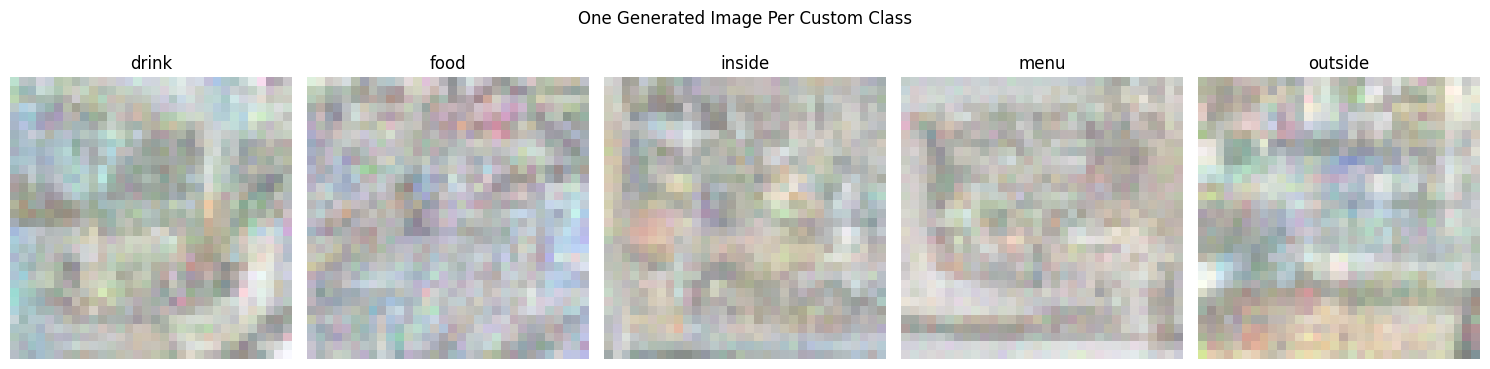

In [29]:
import torchvision.models as models
import torch.nn as nn
from torchvision import transforms
import torch

# 1. Load pretrained classifier (ResNet18)
classifier = models.resnet18(pretrained=True).to(device)
classifier.eval()

# 2. ImageNet preprocessing
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 3. Get your custom class labels from the dataset
custom_class_names = full_dataset.classes  # e.g., ['drink', 'food', 'inside', 'menu', 'outside']

# 4. Generate many images (for better class variety)
generated_images = sample_images(model, noise_scheduler, num_images=300, inference_steps=25).to(device)

# 5. Preprocess and classify
processed = preprocess(generated_images)
preds = classifier(processed).argmax(1).cpu().numpy()

# 6. Group one image per class from your custom labels
selected = {}
for img, pred_imgnet in zip(generated_images, preds):
    # You must map or simulate predicted labels to your 5 custom labels
    # Here's a placeholder rule — REPLACE with your logic if needed:
    for label in custom_class_names:
        if label not in selected:
            selected[label] = img.cpu()
            break
    if len(selected) == len(custom_class_names):
        break

# 7. Plot images with titles (custom class labels)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(selected), figsize=(15, 4))

for ax, (label, img) in zip(axes, selected.items()):
    ax.imshow((img.permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1))
    ax.set_title(label)
    ax.axis("off")

plt.suptitle("One Generated Image Per Custom Class")
plt.tight_layout()
plt.show()

In [32]:
from google.colab import files
files.download(save_path)

# Save model checkpoint
save_path = "/content/ddpm_model.pth"
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

# Download to local machine
from google.colab import files
files.download(save_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model saved to /content/ddpm_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>